# Sequential API

In [ ]:
import torch.nn as nn

model = nn.Sequential(
    nn.Linear(10, 5),
    nn.ReLU(),
    nn.Linear(5, 2)
)

In [ ]:
print(model)

Sequential(
  (0): Linear(in_features=10, out_features=5, bias=True)
  (1): ReLU()
  (2): Linear(in_features=5, out_features=2, bias=True)
)


In [ ]:
!pip install torch-summary
from torchsummary import summary

summary(model, input_size=(1, 10))

Layer (type:depth-idx)                   Param #
├─Linear: 1-1                            55
├─ReLU: 1-2                              --
├─Linear: 1-3                            12
Total params: 67
Trainable params: 67
Non-trainable params: 0


Layer (type:depth-idx)                   Param #
├─Linear: 1-1                            55
├─ReLU: 1-2                              --
├─Linear: 1-3                            12
Total params: 67
Trainable params: 67
Non-trainable params: 0

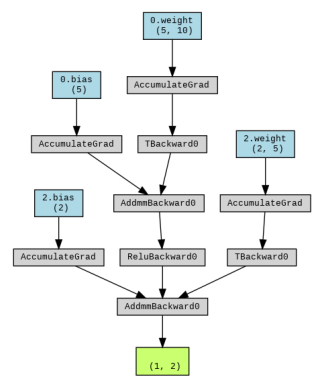

In [ ]:
!pip install torchviz
import torch
from torchviz import make_dot
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

x = torch.randn(1, 10)
y = model(x)
make_dot(y, params=dict(model.named_parameters())).render("model", format="png")

img = mpimg.imread('model.png')
imgplot = plt.imshow(img)
plt.axis('off')
plt.show()

# Custom API

In [ ]:
class NeuralNetwork(nn.Module):
    def __init__(self, output_dim_1, output_dim_2, output_dim_3):
        super().__init__()
        self.flatten = nn.Flatten()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(28*28, output_dim_1),
            nn.ReLU(),
            nn.Linear(output_dim_1, output_dim_2),
            nn.ReLU(),
            nn.Linear(output_dim_2, output_dim_3, bias = False),
        )

    def forward(self, x):
        x = self.flatten(x)
        logits = self.linear_relu_stack(x)
        return logits

model = NeuralNetwork(512, 512, 10)
print(model)

NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=10, bias=False)
  )
)


Padding + Embedding

In [ ]:
import torch
import torch.nn as nn
import numpy as np
from torch.nn.utils.rnn import pad_sequence

sentences = [
    "I love banana.",
    "I also love NLP",
    "NLP is interesting",
    "I am studing NLP",
    "NLP is fun"
]

tokenized_sentences = [sentence.split() for sentence in sentences]

vocab = {}
for sentence in tokenized_sentences:
    for word in sentence:
        if word not in vocab:
            vocab[word] = len(vocab) + 1  # 단어에 고유한 인덱스 부여 (0은 패딩용으로 예약)

indexed_sentences = [[vocab[word] for word in sentence] for sentence in tokenized_sentences]

print("Indexed Sentences:", indexed_sentences)

tensor_sentences = [torch.tensor(sentence, dtype=torch.long) for sentence in indexed_sentences]

# pad_sequence 사용 예시
padded_sentences = pad_sequence(tensor_sentences, batch_first=True, padding_value=0)

print("Padded Sentences Tensor:")
print(padded_sentences)

Indexed Sentences: [[1, 2, 3], [1, 4, 2, 5], [5, 6, 7], [1, 8, 9, 5], [5, 6, 10]]
Padded Sentences Tensor:
tensor([[ 1,  2,  3,  0],
        [ 1,  4,  2,  5],
        [ 5,  6,  7,  0],
        [ 1,  8,  9,  5],
        [ 5,  6, 10,  0]])


In [ ]:
embedding_dim = 8  # 임베딩 차원 (각 단어를 8차원 벡터로 변환)
vocab_size = len(vocab) + 1  # 단어 사전 크기 (+1은 특수토큰 <pad> 0을 포함)

# 임베딩 레이어 (vocab_size의 단어를 embedding_dim 크기의 벡터로 변환)
embedding_layer = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)

# 임베딩 레이어를 통과한 결과
embedded_sentences = embedding_layer(padded_sentences)

print("Embedded Sentences Tensor:")
print(embedded_sentences.shape)  # 출력: (batch_size, 문장 길이, embedding_dim)
print(embedded_sentences)

Embedded Sentences Tensor:
torch.Size([5, 4, 8])
tensor([[[ 0.6928,  2.4359, -0.6768, -0.6062,  1.1268, -0.7230, -1.3211,
           1.5084],
         [-0.6315, -1.1301,  0.4238,  1.0645, -2.5249,  0.1292, -0.4115,
           0.5469],
         [ 0.8104,  0.1009, -1.1710,  0.3955,  0.0365, -0.8891,  0.8132,
          -0.2375],
         [ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
           0.0000]],

        [[ 0.6928,  2.4359, -0.6768, -0.6062,  1.1268, -0.7230, -1.3211,
           1.5084],
         [ 0.6163, -0.5618, -0.7639,  0.4036, -0.5046,  1.2746,  0.3161,
          -1.5950],
         [-0.6315, -1.1301,  0.4238,  1.0645, -2.5249,  0.1292, -0.4115,
           0.5469],
         [ 0.8571,  1.0658,  2.3878,  2.0994,  1.1599, -0.4234, -0.2166,
           1.2916]],

        [[ 0.8571,  1.0658,  2.3878,  2.0994,  1.1599, -0.4234, -0.2166,
           1.2916],
         [-0.2568,  1.9863, -0.8996, -0.2916,  0.0580,  0.1519,  0.8500,
          -0.1222],
         [-0.1023

# Optimizer

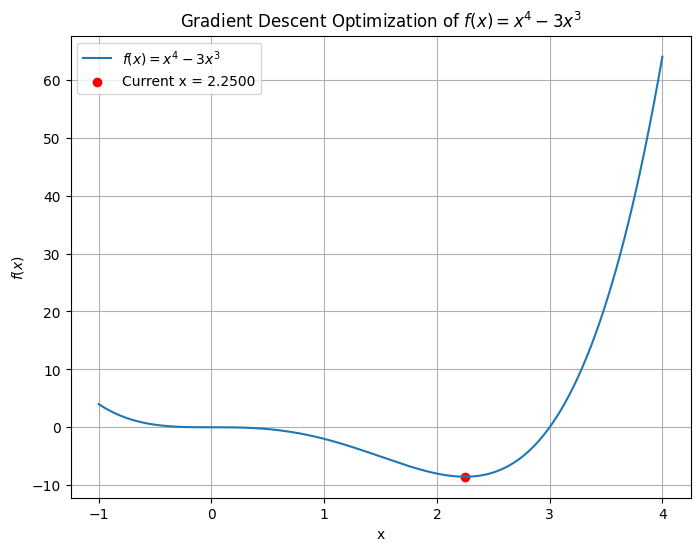

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output

def f(x):
    return x**4 - 3 * x**3

def f_prime(x):
    return 4 * x**3 - 9 * x**2

x_old = 0
x_new = 6 # 시작점
eps = 0.01 # 학습률 (스텝 크기)
precision = 0.00001 # 최적화 기준점 (반복문 탈출 조건)

x = np.linspace(-1, 4, 400)
y = f(x)

while abs(x_new - x_old) > precision:
    x_old = x_new
    x_new = x_old - eps * f_prime(x_old)

    clear_output(wait=True)

    plt.figure(figsize=(8, 6))
    plt.plot(x, y, label=r"$f(x) = x^4 - 3x^3$")
    plt.scatter(x_new, f(x_new), color="red", label=rf"Current x = {x_new:.4f}")
    plt.title(r"Gradient Descent Optimization of $f(x) = x^4 - 3x^3$")
    plt.xlabel("x")
    plt.ylabel(r"$f(x)$")
    plt.legend()
    plt.grid(True)
    plt.show()

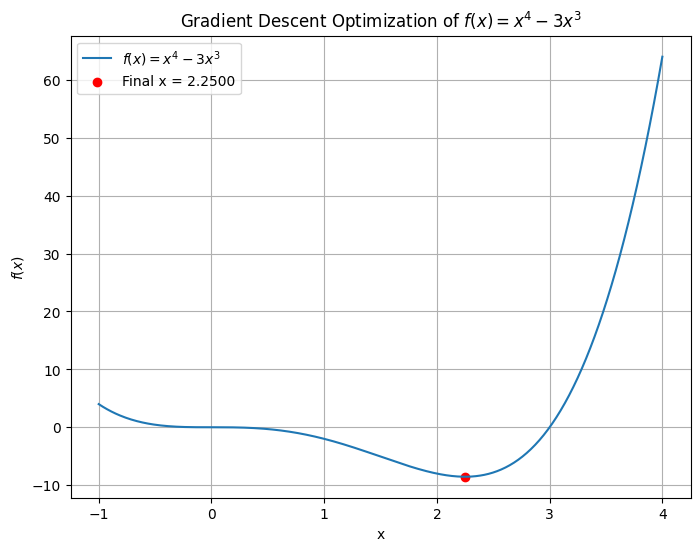

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt

def f(x):
    return x**4 - 3 * x**3

# 시작점
x = torch.tensor([6.0], requires_grad=True)

learning_rate = 0.01

# Pytorch의 Optimizer
optimizer = torch.optim.SGD([x], lr=learning_rate)

x_vals = np.linspace(-1, 4, 400)
y_vals = f(x_vals)

precision = 0.00001
x_old = x.clone().detach()

while True:
    optimizer.zero_grad()
    loss = x**4 - 3 * x**3
    loss.backward()
    optimizer.step()

    if torch.abs(x - x_old) < precision:
        break
    x_old = x.clone().detach()

plt.figure(figsize=(8, 6))
plt.plot(x_vals, y_vals, label=r"$f(x) = x^4 - 3x^3$")
plt.scatter(x.item(), f(x.item()), color="red", label=rf"Final x = {x.item():.4f}")
plt.title(r"Gradient Descent Optimization of $f(x) = x^4 - 3x^3$")
plt.xlabel("x")
plt.ylabel(r"$f(x)$")
plt.legend()
plt.grid(True)
plt.show()


## Loss Function
회귀 예시

In [ ]:
import torch
import torch.nn as nn

prediction = torch.tensor([[2.0], [3.0], [4.0]])
ground_truth = torch.tensor([[2.5], [3.5], [5.0]])

criterion = nn.MSELoss()
loss = criterion(prediction, ground_truth)

print(f'손실 값: {loss.item()}')

손실 값: 0.5


분류 예시

In [ ]:
import torch
import torch.nn as nn

# 예시 예측 값 (강아지 vs 고양이)
predictions = torch.tensor([[0.8, 0.2], [0.4, 0.6], [0.9, 0.1]])
# 실제 레이블 (강아지: 0, 고양이: 1)
labels = torch.tensor([0, 1, 0])

criterion = nn.CrossEntropyLoss()
loss = criterion(predictions, labels)

print(f'손실 값: {loss.item()}')

손실 값: 0.4689091742038727


## VGG 16 구현

## RNN 구현